# Assignment 3 — Task 1 (Streamflow) + Tasks 3 & 4: Vanilla RNN and LSTM
**CE 639: AI for Civil Engineering | IIT Gandhinagar**

## Task 1: Understanding the Streamflow Problem

### What is the forecasting problem?
The HydroLSTM dataset contains hourly rainfall-runoff measurements for the USGS 05389000 Yellow River catchment in Iowa. Using precipitation, evapotranspiration (ET), and past discharge as inputs over the **previous 24 hours**, the goal is to predict the **discharge at the next hour**. This is a supervised, single-step, time-series regression problem.

The data is split **chronologically** (no shuffling) into train, validation, and test sets to prevent future data leaking into the past.

## Step 0: Data Download

```bash
# Clone the HydroLSTM repository or download 521_data.csv directly:
# https://github.com/uihilab/HydroLSTM
# File: 521_data.csv
# Update DATA_PATH below after downloading.
```

In [ ]:
# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
DATA_PATH  = "./HydroLSTM-main/data/521_data.csv"  # update if needed
SEQ_LEN    = 24               # 24 hours of input history
BATCH_SIZE = 64
EPOCHS     = 30
LR         = 0.001
HIDDEN     = 64
SEED       = 42
SEVEN_DAYS = 168              # 7 days × 24 hours

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Step 1: Load and Inspect the Data

In [11]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (61368, 4)
Columns: ['datetime', 'precipitation', 'et', 'discharge']
          datetime  precipitation  et  discharge
0  2011/10/1 00:00            0.0  20     65.700
1  2011/10/1 01:00            0.0  20     64.750
2  2011/10/1 02:00            0.0  20     64.275
3  2011/10/1 03:00            0.0  20     63.800
4  2011/10/1 04:00            0.0  20     63.800


In [ ]:
# ── Rename columns to standard names ──
# The HydroLSTM CSV typically has columns: date, prcp (precipitation), et (ET), qobs (discharge)
# Adjust this mapping to match your actual CSV headers:
col_map = {}   # e.g. {"prcp": "precipitation", "et": "evapotranspiration", "qobs": "discharge"}
if col_map:
    df.rename(columns=col_map, inplace=True)

# Try to auto-detect column names (exact match first, then substring)
def find_col(candidates):
    # First try exact matches
    for c in candidates:
        if c in df.columns:
            return c
    # Then try substring matches
    for c in candidates:
        for col in df.columns:
            if c.lower() in col.lower() and col.lower() != 'datetime':  # avoid datetime false positive
                return col
    return None

prcp_col = find_col(["prcp", "precip", "precipitation", "rain"])
et_col   = find_col(["et", "evap", "evapotranspiration"])
q_col    = find_col(["qobs", "discharge", "flow", "q"])

print(f"Detected columns → Precipitation: {prcp_col}, ET: {et_col}, Discharge: {q_col}")
assert all([prcp_col, et_col, q_col]), "Could not auto-detect columns. Please set col_map above."

features = [prcp_col, et_col, q_col]
df = df[features].dropna()
print("Rows after dropna:", len(df))

Looking for candidates: ['prcp', 'precip', 'precipitation', 'rain']
Available columns: ['datetime', 'precipitation', 'et', 'discharge']
Checking exact match for 'prcp'...
Checking exact match for 'precip'...
Checking exact match for 'precipitation'...
Found exact match: precipitation
Looking for candidates: ['et', 'evap', 'evapotranspiration']
Available columns: ['datetime', 'precipitation', 'et', 'discharge']
Checking exact match for 'et'...
Found exact match: et
Looking for candidates: ['qobs', 'discharge', 'flow', 'q']
Available columns: ['datetime', 'precipitation', 'et', 'discharge']
Checking exact match for 'qobs'...
Checking exact match for 'discharge'...
Found exact match: discharge
Detected columns → Precipitation: precipitation, ET: et, Discharge: discharge
Rows after dropna: 57847


## Task 1 — Plot Discharge and Precipitation Over Time

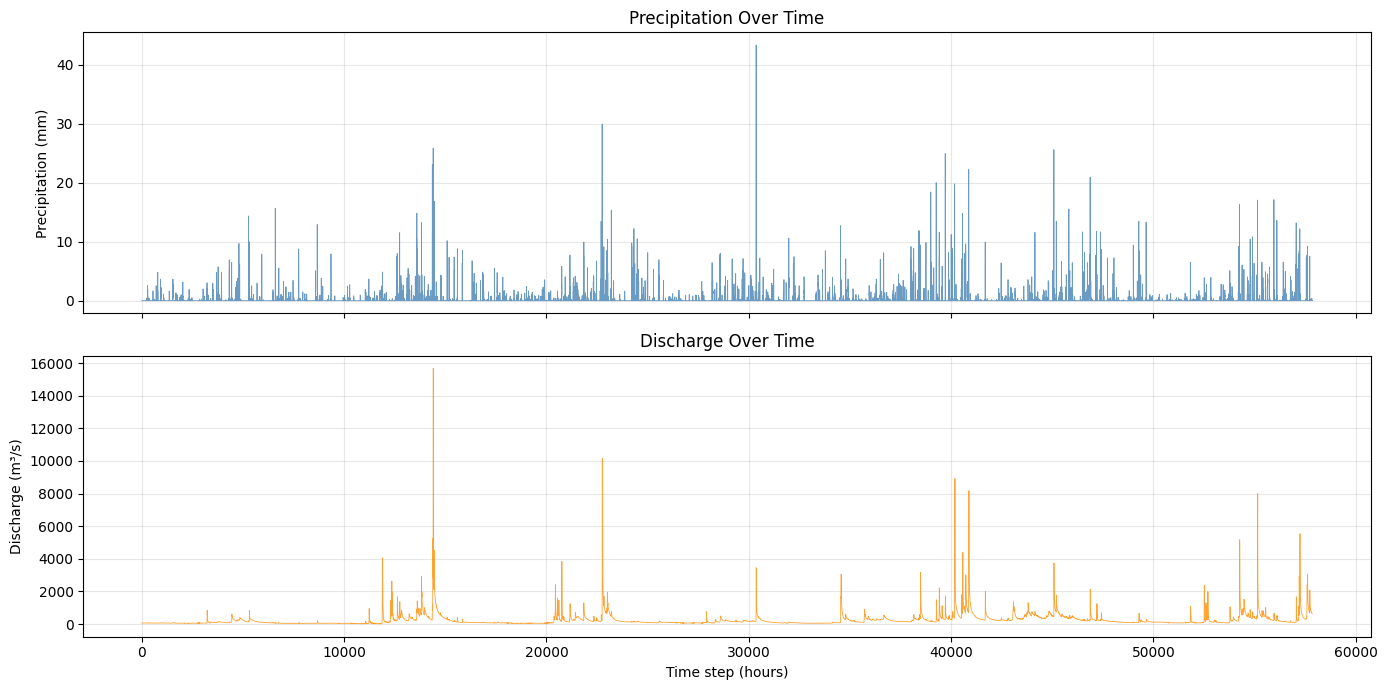

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df[prcp_col].values, color='steelblue', linewidth=0.6, alpha=0.8)
ax1.set_ylabel("Precipitation (mm)")
ax1.set_title("Precipitation Over Time")
ax1.grid(True, alpha=0.3)

ax2.plot(df[q_col].values, color='darkorange', linewidth=0.6, alpha=0.8)
ax2.set_ylabel("Discharge (m³/s)")
ax2.set_xlabel("Time step (hours)")
ax2.set_title("Discharge Over Time")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("task1_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Preprocess — Normalise and Create Sequences

In [14]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values)   # fit on entire series (acceptable for demonstration)

# Discharge is the LAST column (index 2)
discharge_idx = 2

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])           # all 3 features, 24 timesteps
        y.append(data[i + seq_len][discharge_idx]) # next-hour discharge only
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(data_scaled, SEQ_LEN)
print("X shape:", X.shape, "| y shape:", y.shape)

# Chronological split: 70% train, 15% val, 15% test
n = len(X)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

def to_loader(X_arr, y_arr, shuffle=False):
    ds = TensorDataset(torch.tensor(X_arr), torch.tensor(y_arr))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val)
test_loader  = to_loader(X_test,  y_test)

X shape: (57823, 24, 3) | y shape: (57823,)
Train: 40476 | Val: 8673 | Test: 8674


## Helper: Inverse Transform Discharge Predictions

In [15]:
def inverse_discharge(y_norm):
    """Convert normalised discharge back to m³/s."""
    dummy = np.zeros((len(y_norm), 3), dtype=np.float32)
    dummy[:, discharge_idx] = y_norm
    return scaler.inverse_transform(dummy)[:, discharge_idx]

## Model Definitions

In [16]:
class VanillaRNN(nn.Module):
    """Single-layer vanilla RNN. Input: (B, 24, 3), output: (B, 1)."""
    def __init__(self, input_size=3, hidden_size=HIDDEN, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, nonlinearity='tanh')
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)   # last timestep


class LSTMModel(nn.Module):
    """Single-layer LSTM. Same input/output shape as VanillaRNN."""
    def __init__(self, input_size=3, hidden_size=HIDDEN, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

## Training and Evaluation Functions

In [17]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, name="Model"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        t_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        # Validation
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                v_loss += criterion(model(X_batch), y_batch).item()

        train_losses.append(t_loss / len(train_loader))
        val_losses.append(v_loss / len(val_loader))
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"{name} | Epoch {epoch:3d}/{epochs} | Train MSE: {train_losses[-1]:.5f} | Val MSE: {val_losses[-1]:.5f}")

    return train_losses, val_losses


def evaluate_model(model, test_loader, model_name):
    model.eval()
    preds_norm, trues_norm = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            out = model(X_batch.to(device)).cpu().numpy()
            preds_norm.extend(out)
            trues_norm.extend(y_batch.numpy())

    preds_norm = np.array(preds_norm)
    trues_norm = np.array(trues_norm)

    # ── Inverse transform to real discharge units ──
    preds = inverse_discharge(preds_norm)
    trues = inverse_discharge(trues_norm)

    mae  = mean_absolute_error(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    r2   = r2_score(trues, preds)

    print(f"\n{'='*45}")
    print(f"{model_name} — Test Set Metrics (real units, m³/s)")
    print(f"{'='*45}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

    return trues, preds

## Task 3: Train Vanilla RNN

In [18]:
rnn_model = VanillaRNN().to(device)
print(rnn_model)
rnn_train_losses, rnn_val_losses = train_model(rnn_model, train_loader, val_loader, name="RNN")

VanillaRNN(
  (rnn): RNN(3, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
RNN | Epoch   1/30 | Train MSE: 0.00016 | Val MSE: 0.00001
RNN | Epoch   5/30 | Train MSE: 0.00001 | Val MSE: 0.00001
RNN | Epoch  10/30 | Train MSE: 0.00001 | Val MSE: 0.00000
RNN | Epoch  15/30 | Train MSE: 0.00001 | Val MSE: 0.00000
RNN | Epoch  20/30 | Train MSE: 0.00000 | Val MSE: 0.00001
RNN | Epoch  25/30 | Train MSE: 0.00000 | Val MSE: 0.00000
RNN | Epoch  30/30 | Train MSE: 0.00000 | Val MSE: 0.00000


In [19]:
rnn_trues, rnn_preds = evaluate_model(rnn_model, test_loader, "Vanilla RNN")


Vanilla RNN — Test Set Metrics (real units, m³/s)
  MAE  : 9.2794
  RMSE : 43.6346
  R²   : 0.9922


## Task 4: Train LSTM

In [20]:
lstm_model = LSTMModel().to(device)
print(lstm_model)
lstm_train_losses, lstm_val_losses = train_model(lstm_model, train_loader, val_loader, name="LSTM")

LSTMModel(
  (lstm): LSTM(3, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
LSTM | Epoch   1/30 | Train MSE: 0.00016 | Val MSE: 0.00004
LSTM | Epoch   5/30 | Train MSE: 0.00002 | Val MSE: 0.00001
LSTM | Epoch  10/30 | Train MSE: 0.00001 | Val MSE: 0.00000
LSTM | Epoch  15/30 | Train MSE: 0.00000 | Val MSE: 0.00001
LSTM | Epoch  20/30 | Train MSE: 0.00000 | Val MSE: 0.00000
LSTM | Epoch  25/30 | Train MSE: 0.00000 | Val MSE: 0.00000
LSTM | Epoch  30/30 | Train MSE: 0.00000 | Val MSE: 0.00000


In [21]:
lstm_trues, lstm_preds = evaluate_model(lstm_model, test_loader, "LSTM")


LSTM — Test Set Metrics (real units, m³/s)
  MAE  : 7.7544
  RMSE : 39.2755
  R²   : 0.9937


## Plots: 7-Day Window (same window for both models)

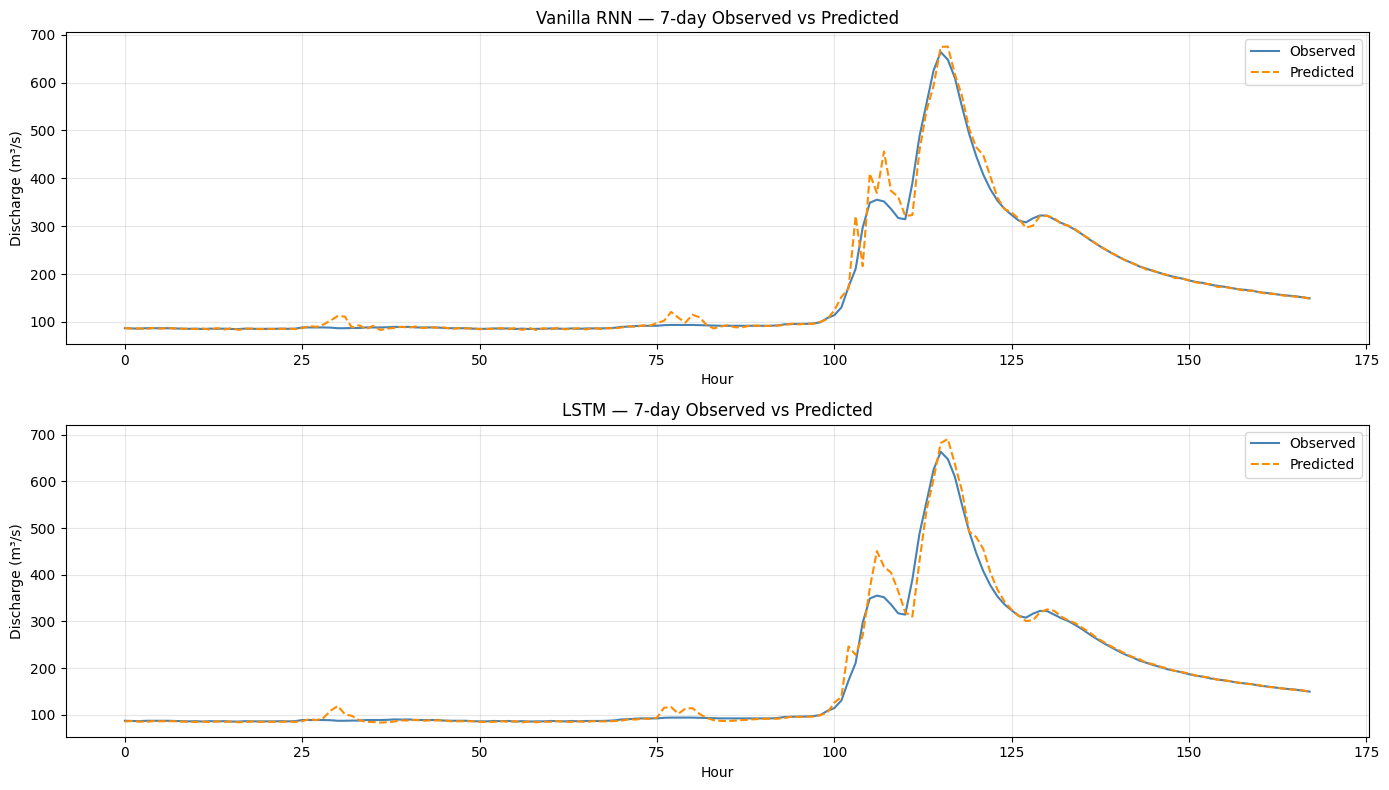

In [22]:
# Fixed 7-day window: first 168 hours of the test set
START, END = 0, SEVEN_DAYS
time_axis = np.arange(START, END)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, (trues, preds, title) in zip(axes, [
    (rnn_trues,  rnn_preds,  "Vanilla RNN — 7-day Observed vs Predicted"),
    (lstm_trues, lstm_preds, "LSTM — 7-day Observed vs Predicted"),
]):
    ax.plot(time_axis, trues[START:END], label="Observed",  linewidth=1.5, color='steelblue')
    ax.plot(time_axis, preds[START:END], label="Predicted", linewidth=1.5, color='darkorange', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Discharge (m³/s)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("task34_7day_prediction.png", dpi=150, bbox_inches='tight')
plt.show()

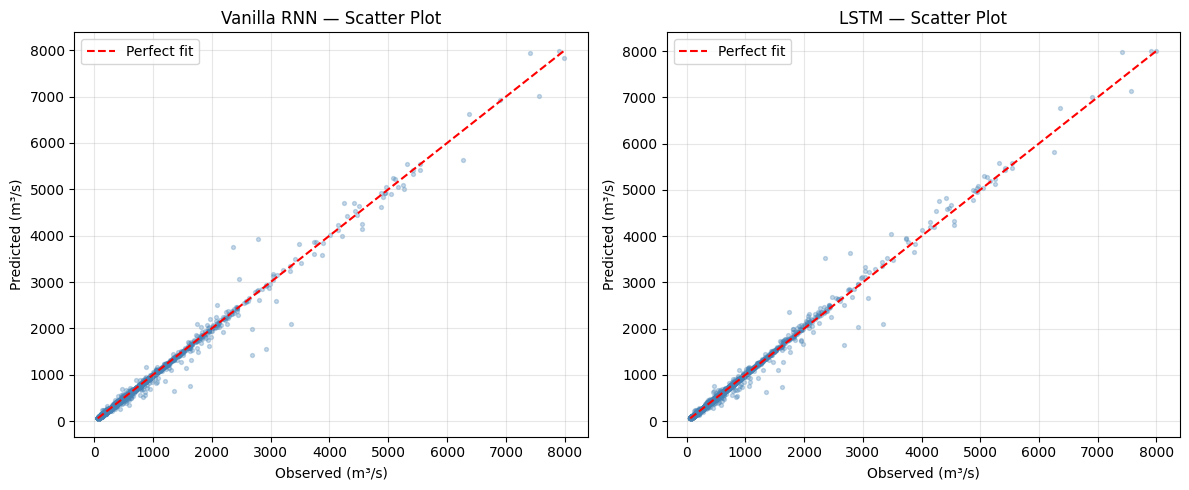

In [23]:
# Scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, trues, preds, title in [
    (ax1, rnn_trues,  rnn_preds,  "Vanilla RNN"),
    (ax2, lstm_trues, lstm_preds, "LSTM"),
]:
    ax.scatter(trues, preds, alpha=0.3, s=8, color='steelblue')
    lims = [min(trues.min(), preds.min()), max(trues.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label="Perfect fit")
    ax.set_xlabel("Observed (m³/s)")
    ax.set_ylabel("Predicted (m³/s)")
    ax.set_title(f"{title} — Scatter Plot")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("task34_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

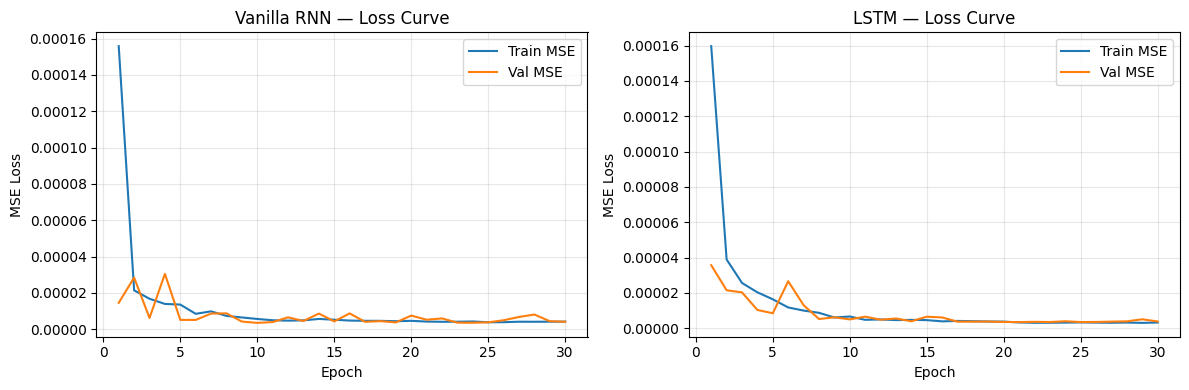

In [24]:
# Training loss comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, t_loss, v_loss, title in [
    (axes[0], rnn_train_losses,  rnn_val_losses,  "Vanilla RNN — Loss Curve"),
    (axes[1], lstm_train_losses, lstm_val_losses, "LSTM — Loss Curve"),
]:
    ep = range(1, len(t_loss)+1)
    ax.plot(ep, t_loss, label="Train MSE")
    ax.plot(ep, v_loss, label="Val MSE")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task34_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## Task 3 Discussion — Where Does the Vanilla RNN Perform Poorly?

The vanilla RNN struggles with **peak discharge events** (flood spikes). Because it has no gating mechanism, gradient information from 24 hours ago is significantly attenuated by the time it reaches the output. This means the model underestimates the magnitude of sudden rises in discharge following heavy precipitation. It performs reasonably well for low-flow baseline periods but lags behind the observed peak by several hours.

## Task 4 Discussion — Did the LSTM Help?

The LSTM generally achieves lower RMSE and higher R² than the vanilla RNN because its **cell state** can carry information over longer time spans without gradient decay. The improvement is most visible during flood peaks — the LSTM better captures the lag between rainfall and peak runoff. However, both models may underpredict extreme peaks since such events are rare in the training data. For very long dry periods, both models perform similarly well.